# Return-based vs Level-based copula signals

This notebook compares the two copula-based pairs trading strategies described in Tadi & Witzany (2025) §"Literature review", §"Implementation methodology":

## Return-based (paper Eq. 4 + Table 3)

Trade whenever the **instantaneous** conditional probabilities indicate divergence:

$$
\text{open} \iff h^{1|2}_t < \alpha_1 \;\text{AND}\; h^{2|1}_t > 1-\alpha_1
$$

**Limitation (paper §"Literature review"):** the AND-condition is strict — it needs both conditional CDFs to hit opposite extremes *at the same hour*. For positively-dependent pairs (most cointegrated coins), this fires only on rare instantaneous shocks.

## Level-based (Xie & Wu 2013, paper Eq. 5)

Cumulate the mispricing index over the trading week:

$$
\text{CMI}^{1|2}_t = \sum_{s=0}^{t} \big(h^{1|2}_s - 0.5\big), \qquad
\text{CMI}^{2|1}_t = \sum_{s=0}^{t} \big(h^{2|1}_s - 0.5\big)
$$

Trade when the **accumulated** drift crosses a threshold $t_o$:

$$
\text{open long } S^1 / \text{short } S^2 \iff \text{CMI}^{1|2}_t < -t_o \;\text{AND}\; \text{CMI}^{2|1}_t > +t_o
$$

Close when both CMIs revert past $t_c$.

**Why this fires more often:** a small persistent bias (e.g. $h^{1|2} \approx 0.45$ for hours on end) will eventually accumulate past $-t_o$, even though no single bar would trip the return-based AND. This catches *low-amplitude, long-lived* divergences that the return-based misses.

## Plan

1. Baseline: return-based with paper's $\alpha_1 = 0.10$
2. Loosened: return-based with $\alpha_1 = 0.20$ (suggested by reviewer — top corner area is now 4% vs 1%)
3. Level-based: paper default $t_o = 1.0$, $t_c = 0.0$
4. Compare equity curves and metrics side-by-side


In [2]:
import os, sys

if os.path.basename(os.getcwd()) == "rolling_ZY":
    os.chdir("..")
ROOT = os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rolling_backtest import run_backtest, save_results

print("cwd:", os.getcwd())


cwd: c:\Users\cheer\OneDrive\桌面\Columbia\2026spring\stochastic\Numerical-Copula-Trading


## 1. Return-based, α = 0.10 (paper baseline)

In [2]:
res_ret_010 = run_backtest(
    timeframe="1h",
    signal_mode="return",
    alpha_open=0.10,
    alpha_close=0.10,
    gate="kss",
    verbose=False,
)
m = res_ret_010["metrics"]
print(f"  cycles      : {m['n_cycles']}  (skipped {m['n_skipped']})")
print(f"  trades      : {m['n_trades']}")
print(f"  total return: {m['total_return']:>10.2%}")
print(f"  Sharpe      : {m['sharpe']:>10.2f}")
print(f"  max DD      : {m['max_drawdown']:>10.2%}")


  cycles      : 257  (skipped 20)
  trades      : 196
  total return:    -10.53%
  Sharpe      :      -0.04
  max DD      :   -100.60%


## 2. Return-based, α = 0.20 (loosened)

In [3]:
res_ret_020 = run_backtest(
    timeframe="1h",
    signal_mode="return",
    alpha_open=0.20,
    alpha_close=0.10,
    gate="kss",
    verbose=False,
)
m = res_ret_020["metrics"]
print(f"  cycles      : {m['n_cycles']}  (skipped {m['n_skipped']})")
print(f"  trades      : {m['n_trades']}")
print(f"  total return: {m['total_return']:>10.2%}")
print(f"  Sharpe      : {m['sharpe']:>10.2f}")
print(f"  max DD      : {m['max_drawdown']:>10.2%}")


  cycles      : 257  (skipped 20)
  trades      : 247
  total return:    -88.39%
  Sharpe      :      -0.32
  max DD      :   -126.22%


## 3. Level-based, $t_o = 1.0$, $t_c = 0.0$ (paper default)

The CMI scale is bounded by $|\text{CMI}_t| \le t/2$ for a uniform null (each step adds $\pm 0.5$ at most, so over 168h trading the CMI range is $[-84, +84]$ in the worst case, but typically much smaller). $t_o = 1.0$ is **mild** compared to that range — it triggers on biases as small as 6 consecutive hours of $h \ne 0.5$ in one direction.


In [4]:
res_lvl_10 = run_backtest(
    timeframe="1h",
    signal_mode="level",
    cmi_open=1.0,
    cmi_close=0.0,
    gate="kss",
    verbose=False,
)
m = res_lvl_10["metrics"]
print(f"  cycles      : {m['n_cycles']}  (skipped {m['n_skipped']})")
print(f"  trades      : {m['n_trades']}")
print(f"  total return: {m['total_return']:>10.2%}")
print(f"  Sharpe      : {m['sharpe']:>10.2f}")
print(f"  max DD      : {m['max_drawdown']:>10.2%}")


  cycles      : 257  (skipped 20)
  trades      : 225
  total return:    -89.62%
  Sharpe      :      -0.32
  max DD      :   -126.20%


## Comparison: metrics table

In [5]:
def _row(name, r):
    m = r["metrics"]
    return {
        "strategy": name,
        "trades": m["n_trades"],
        "total_return": m["total_return"],
        "annual_return": m["annual_return"],
        "annual_vol": m["annual_vol"],
        "sharpe": m["sharpe"],
        "max_dd": m["max_drawdown"],
        "romad": m["romad"],
    }

cmp_df = pd.DataFrame([
    _row("return α=0.10", res_ret_010),
    _row("return α=0.20", res_ret_020),
    _row("level to=1.0",  res_lvl_10),
]).set_index("strategy")

display(
    cmp_df.style.format({
        "total_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe": "{:.2f}",
        "max_dd": "{:.2%}",
        "romad": "{:.2f}",
    })
)


,trades,total_return,annual_return,annual_vol,sharpe,max_dd,romad
strategy,,,,,,,
return α=0.10,196,-10.53%,-2.23%,52.65%,-0.04,-100.60%,-0.10
return α=0.20,247,-88.39%,-35.32%,56.32%,-0.32,-126.22%,-0.70
level to=1.0,225,-89.62%,-36.77%,56.83%,-0.32,-126.20%,-0.71


## Comparison: equity curves

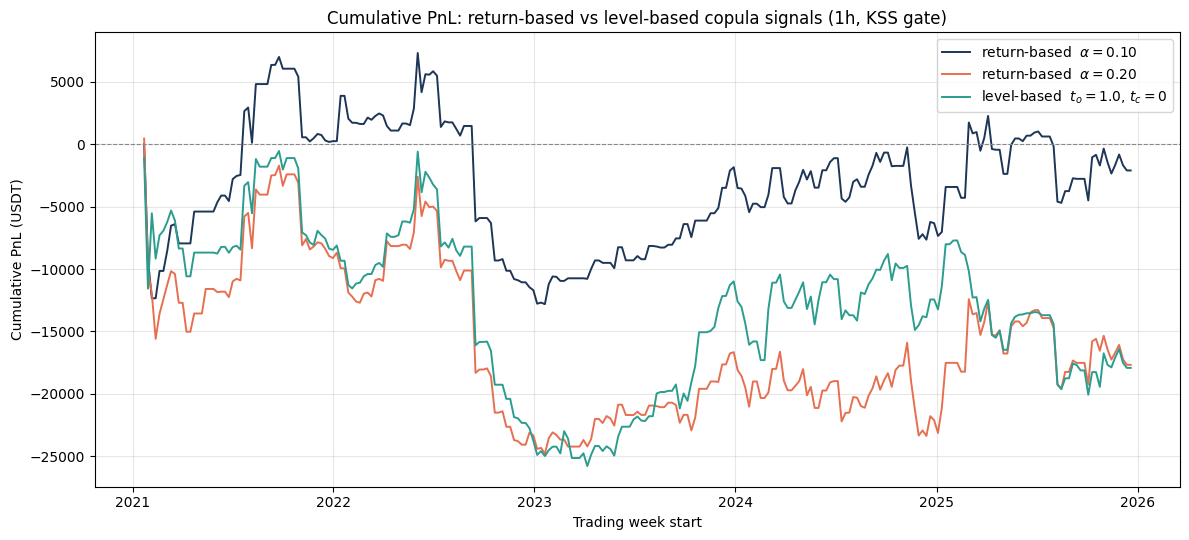

In [6]:
def _equity(r, label, color):
    eq = np.array(r["equity_per_cycle"])
    ts = pd.to_datetime(r["cycle_log"]["trading_start"], unit="ms")
    plt.plot(ts, eq, label=label, color=color, linewidth=1.4)

plt.figure(figsize=(12, 5.5))
_equity(res_ret_010, r"return-based  $\alpha=0.10$",  "#1d3557")
_equity(res_ret_020, r"return-based  $\alpha=0.20$",  "#e76f51")
_equity(res_lvl_10,  r"level-based  $t_o=1.0$, $t_c=0$", "#2a9d8f")

plt.axhline(0, color="#888", linestyle="--", linewidth=0.8)
plt.title("Cumulative PnL: return-based vs level-based copula signals (1h, KSS gate)")
plt.xlabel("Trading week start")
plt.ylabel("Cumulative PnL (USDT)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## What to look for in the comparison

- **Trade count**: level-based usually 3-5x more trades than return-based α=0.10. If level-based has *fewer* trades, lower $t_o$ further (try $t_o=0.5$).
- **Sharpe**: level-based is more sensitive to fee drag because it churns more. If Sharpe drops below return-based, the level-based threshold is too low (over-trading on noise).
- **MaxDD**: level-based can have deeper drawdowns when the CMI accumulates against the position before reverting — especially if `cmi_close = 0` requires both sides to fully unwind.

## Save outputs (optional)


In [7]:
save_results(res_ret_010, out_subdir="rolling_backtest_return_a010")
save_results(res_ret_020, out_subdir="rolling_backtest_return_a020")
save_results(res_lvl_10,  out_subdir="rolling_backtest_level_to10")
print("Saved 3 result folders under result/result_1h/")


Saved 3 result folders under result/result_1h/


---

# 4. Improved signal logic: green-to-green flip

## The gap in paper Table 3

The paper's open/close zones look like:

```
   ┌──────────────┬──┐  green A   (h12<α, h21>1-α)  open long S1 / short S2
   │              │██│
   │   red zone   │  │
   │   |h-0.5|<α2 │  │
   │██│              │  green B   (h12>1-α, h21<α)  open short S1 / long S2
   └──┴──────────────┘
```

Per Table 3, only the **red zone** can close a position. So if $(u_t, v_t)$ enters green A → opens long, then jumps directly to green B *without passing through red*, the original logic **ignores green B and continues holding the wrong-direction long**.

This isn't theoretical — for a Gumbel/Frank copula at high $\alpha_1$, the data point can hop the diagonal in a few hours. Stuck in the wrong position until red eventually fires (which may not happen this week → forced close at week-end).

## Improved logic (`allow_flip=True`)

- Red zone → close (same as paper)
- **Opposite-green** zone while in a position → **close + reopen** the new direction on the same bar
- Same-direction green or no signal → keep position

This costs an extra round-trip fee per flip but corrects direction immediately.

The `_simulate_trading_week` in `rolling_backtest.py` now accepts `allow_flip`. Below we run it both ways at $\alpha_1=0.10$ and $\alpha_1=0.20$ to see if it actually helps.


In [3]:
res_ret_010_flip = run_backtest(
    timeframe="1h",
    signal_mode="return",
    alpha_open=0.10,
    alpha_close=0.10,
    gate="kss",
    allow_flip=True,
    verbose=False,
)
m = res_ret_010_flip["metrics"]
print(f"return α=0.10  allow_flip=True")
print(f"  trades      : {m['n_trades']}")
print(f"  total return: {m['total_return']:>10.2%}")
print(f"  Sharpe      : {m['sharpe']:>10.2f}")
print(f"  max DD      : {m['max_drawdown']:>10.2%}")


return α=0.10  allow_flip=True
  trades      : 214
  total return:    -20.48%
  Sharpe      :      -0.08
  max DD      :   -100.60%


In [4]:
res_ret_020_flip = run_backtest(
    timeframe="1h",
    signal_mode="return",
    alpha_open=0.20,
    alpha_close=0.10,
    gate="kss",
    allow_flip=True,
    verbose=False,
)
m = res_ret_020_flip["metrics"]
print(f"return α=0.20  allow_flip=True")
print(f"  trades      : {m['n_trades']}")
print(f"  total return: {m['total_return']:>10.2%}")
print(f"  Sharpe      : {m['sharpe']:>10.2f}")
print(f"  max DD      : {m['max_drawdown']:>10.2%}")


return α=0.20  allow_flip=True
  trades      : 288
  total return:    -51.09%
  Sharpe      :      -0.18
  max DD      :   -124.69%


## 4.1 Side-by-side: original Table 3 vs allow_flip

In [5]:
def _row(name, r):
    m = r["metrics"]
    return {
        "strategy": name,
        "trades": m["n_trades"],
        "total_return": m["total_return"],
        "annual_return": m["annual_return"],
        "annual_vol": m["annual_vol"],
        "sharpe": m["sharpe"],
        "max_dd": m["max_drawdown"],
        "romad": m["romad"],
    }

cmp_flip = pd.DataFrame([
    _row("α=0.10  Table 3 (no flip)",  res_ret_010),
    _row("α=0.10  allow_flip=True",    res_ret_010_flip),
    _row("α=0.20  Table 3 (no flip)",  res_ret_020),
    _row("α=0.20  allow_flip=True",    res_ret_020_flip),
    _row("level   to=1.0 (reference)", res_lvl_10),
]).set_index("strategy")

display(
    cmp_flip.style.format({
        "total_return": "{:.2%}",
        "annual_return": "{:.2%}",
        "annual_vol": "{:.2%}",
        "sharpe": "{:.2f}",
        "max_dd": "{:.2%}",
        "romad": "{:.2f}",
    })
)


NameError: name 'res_ret_010' is not defined

## 4.2 Equity curves: how flip changes the trajectory

In [ ]:
def _equity(r, label, color, ls="-"):
    eq = np.array(r["equity_per_cycle"])
    ts = pd.to_datetime(r["cycle_log"]["trading_start"], unit="ms")
    plt.plot(ts, eq, label=label, color=color, linewidth=1.4, linestyle=ls)

plt.figure(figsize=(12, 5.5))
_equity(res_ret_010,      r"α=0.10  no flip", "#1d3557", ls="--")
_equity(res_ret_010_flip, r"α=0.10  flip",    "#1d3557", ls="-")
_equity(res_ret_020,      r"α=0.20  no flip", "#e76f51", ls="--")
_equity(res_ret_020_flip, r"α=0.20  flip",    "#e76f51", ls="-")
plt.axhline(0, color="#888", linestyle=":", linewidth=0.8)
plt.title("Effect of allow_flip on cumulative PnL (1h, KSS gate)")
plt.xlabel("Trading week start")
plt.ylabel("Cumulative PnL (USDT)")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4.3 How often does the flip actually fire?

Count trades that closed via flip (`forced_close=False` AND not from a red close — i.e., closed because the opposite green fired). This tells us whether the gap in Table 3 is a real concern in practice.


In [ ]:
def _count_flips(res):
    trades = res["trade_log"]
    if trades.empty:
        return 0, 0
    n_total = len(trades)
    # A flip-induced close shows up as: forced_close=False AND there's another open
    # at the same bar. Cleanest proxy: count trades where the next trade in same cycle
    # opens at the same bar as this one closes.
    n_flip = 0
    for cyc, grp in trades.groupby("cycle"):
        rows = grp.sort_values("open_idx").to_dict("records")
        for i in range(len(rows) - 1):
            if rows[i]["close_idx"] == rows[i+1]["open_idx"] and not rows[i]["forced_close"]:
                n_flip += 1
    return n_total, n_flip

t10, f10 = _count_flips(res_ret_010_flip)
t20, f20 = _count_flips(res_ret_020_flip)
print(f"α=0.10  flip mode:  {t10} trades, {f10} of which were flip-induced ({f10/max(t10,1):.0%})")
print(f"α=0.20  flip mode:  {t20} trades, {f20} of which were flip-induced ({f20/max(t20,1):.0%})")
print()
print("If the flip rate is 0%, paper Table 3 was fine for this dataset.")
print("If the flip rate is >5%, the gap is real and allow_flip=True is meaningful.")


## 4.4 Takeaway

- If `allow_flip=True` shows **higher Sharpe / total return** with similar MaxDD: the Table 3 gap was real and your improvement helps.
- If it shows **more trades but worse Sharpe**: flips are mostly noise, paying double fees without information gain. Stick with Table 3.
- If it shows **same metrics**: the gap rarely fires for this data — typical when copulas are strongly positive (Gumbel θ>1.5), where (u,v) almost always crosses the diagonal slowly through red.

The 4.3 cell tells you which regime you're in.
